# Kalshi & Polymarket Event Study Data Extraction

**Source:** J. Becker  
**Purpose:** Extract market snapshots and trade histories for event study analysis across Kalshi (binary prediction market) and Polymarket (AMM-based market) platforms.

## Overview

This notebook:
1. Downloads compressed archival data (trades, blocks, market snapshots from 2023–2026)
2. Identifies markets active around key event dates (e.g., Ukraine-Russia news, Zelensky lawsuit resolution)
3. Extracts **price snapshots** at 5 am and 5 pm PT on each day in a rolling window
4. Produces both **long-format audit tables** (one row per market-time pair) and **wide-format tables** (one row per market with time-series prices as columns)
5. Generates reference data dictionaries describing column metadata

## Data Caveat

All market snapshots in the archive are **ex-post** (fetched in late February 2026), not collected in real-time during the event windows. Volume/liquidity figures represent full-history values, not contemporaneous measures during the event period. These are a **first-pass approximation** of market activity and interest.

In [ ]:
# =========================================================================
# SECTION: Data Download & Extraction
# =========================================================================
from data_downloader import download_and_extract_data

URL = "https://s3.jbecker.dev/data.tar.zst"
ARCHIVE_NAME = "data.tar.zst"
OUTPUT_DIR = "."

# Call the function to download and extract data
download_and_extract_data(URL, ARCHIVE_NAME, OUTPUT_DIR)

In [ ]:
# =========================================================================
# SECTION: Data Integrity Check & Clean Extraction (Alternative)
# =========================================================================
from data_downloader import verify_and_clean_extraction

URL = "https://s3.jbecker.dev/data.tar.zst"
ARCHIVE_NAME = "data.tar.zst"
OUTPUT_DIR = "."
FORCE_CLEAN = False

# Call the function to verify and clean extraction
verify_and_clean_extraction(URL, ARCHIVE_NAME, OUTPUT_DIR, force_clean=FORCE_CLEAN)

remote_size = 36,020,641,508
local_size  = 36,020,641,508
Done.


## Event Studies: Price Snapshots Around Known Dates

For each event study, we:
1. **Define a time window**: 1 week before the event through 1 week after
2. **Build daily cutoffs**: 5 am and 5 pm Pacific Time in the window
3. **Pull trades**: For each market, find the most recent trade price at each cutoff time using `merge_asof` (backward/"as-of" snapshot logic)
4. **Output formats**:
   - **Snapshots (long)**: One row per (market, cutoff_time), shows the trade timestamp and price nearest to that cutoff
   - **Wide**: One row per market, with columns for each cutoff's price (easier for cross-market time-series analysis)
5. **Parallel extraction**: Top-100 markets (by volume proxy) and topic-filtered markets (Ukraine-related keywords)

**Time zone note**: All cutoffs are computed in Pacific Time (`America/Los_Angeles`), then converted to UTC for trade queries.

## Topic-Filtered Markets: Ukraine-Russia Events

Rather than using full-period top-100 rankings, this section filters for markets explicitly related to Ukraine, Russia, and regional geopolitics. Using a regex search across market titles/descriptions, we extract:
- Markets that match topic keywords (ukraine, russia, putin, nato, etc.)
- Trade history and price snapshots during the same event window (5 am/5 pm PT)

**Note:** Different markets may have different trading patterns and activity levels during the event period compared to the aggregated top-100 set.

In [2]:
from data_processing import extract_event_study

# Topic regex pattern for Ukraine-Russia events
TOPIC_PATTERNS = [
    r"\bukraine\b",
    r"\bukrainian\b",
    r"\brussia\b",
    r"\brussian\b",
    r"\bputin\b",
    r"\bzelensky\b",
    r"\bzelenskyy\b",
    r"\bzelenskyyy\b",
    r"\bzelenskyj\b",
    r"\bkyiv\b",
    r"\bkiev\b",
    r"\bmoscow\b",
    r"\bkremlin\b",
    r"\bdonbas\b",
    r"\bdonetsk\b",
    r"\bluhansk\b",
    r"\bcrimea\b",
    r"\bsevastopol\b",
    r"\bkharkiv\b",
    r"\bodesa\b",
    r"\bodessa\b",
    r"\bzaporizhzhia\b",
    r"\bzaporizhia\b",
    r"\bkherson\b",
    r"\bmariupol\b",
    r"\bnato\b",
]

TOPIC_REGEX = "|".join(TOPIC_PATTERNS)

# Extract event study for March 24, 2025 event
extract_event_study(
    event_start_date="2025-03-24",
    event_end_date="2025-03-24",
    window_days=7,
    topic_regex=TOPIC_REGEX,
    slug="mineral_rights"
)


=== Event Study: MINERAL_RIGHTS ===
Event window: 2025-03-24 to 2025-03-24
Analysis window: 2025-03-17 to 2025-03-31
Final cutoff UTC: 2025-04-01 00:00:00

Polymarket topic markets: 79 -> exports\mineral_rights_pm_topics.csv
Kalshi topic markets: 19 -> exports\mineral_rights_k_topics.csv
Kalshi trades pulled: 14,984
Kalshi long  -> exports\mineral_rights_k_long.csv
Kalshi wide  -> exports\mineral_rights_k_wide.csv
Polymarket trades pulled: 1,035,019
Polymarket long  -> exports\mineral_rights_pm_long.csv
Polymarket wide  -> exports\mineral_rights_pm_wide.csv

Done.



## Zelensky-Suit Event Study

This section repeats the earlier extraction workflow for a different event: the Zelensky lawsuit market resolution window. Since that market took multiple days to resolve, we specify both a **resolution start date** and **resolution end date**, then extract price history from one week before the start through one week after the end.

The workflow mirrors the March 24 event study:
- Top-100 markets by volume active during the window
- Topic-filtered (Ukraine-related) markets
- Price snapshots at 5 am and 5 pm PT each day
- Both long (audit) and wide (time-series) CSV outputs

In [ ]:
from data_processing import extract_event_study

# Topic regex pattern for Ukraine-Russia events
TOPIC_PATTERNS = [
    r"\bukraine\b",
    r"\bukrainian\b",
    r"\brussia\b",
    r"\brussian\b",
    r"\bputin\b",
    r"\bzelensky\b",
    r"\bzelenskyy\b",
    r"\bzelenskyyy\b",
    r"\bzelenskyj\b",
    r"\bkyiv\b",
    r"\bkiev\b",
    r"\bmoscow\b",
    r"\bkremlin\b",
    r"\bdonbas\b",
    r"\bdonetsk\b",
    r"\bluhansk\b",
    r"\bcrimea\b",
    r"\bsevastopol\b",
    r"\bkharkiv\b",
    r"\bodesa\b",
    r"\bodessa\b",
    r"\bzaporizhzhia\b",
    r"\bzaporizhia\b",
    r"\bkherson\b",
    r"\bmariupol\b",
    r"\bnato\b",
]

TOPIC_REGEX = "|".join(TOPIC_PATTERNS)

# Extract event study for March 24, 2025 event
extract_event_study(
    event_start_date="2025-06-30",
    event_end_date="2025-07-08",
    window_days=7,
    topic_regex=TOPIC_REGEX,
    slug="zelensky_suit"
)



=== Event Study: ZELENSKY_SUIT ===
Event window: 2025-06-30 to 2025-07-08
Analysis window: 2025-06-23 to 2025-07-15
Final cutoff UTC: 2025-07-16 00:00:00

Polymarket topic markets: 52 -> exports\zelensky_suit_pm_topics.csv
Kalshi topic markets: 26 -> exports\zelensky_suit_k_topics.csv
Kalshi trades pulled: 11,798
Kalshi long  -> exports\zelensky_suit_k_long.csv
Kalshi wide  -> exports\zelensky_suit_k_wide.csv
Polymarket trades pulled: 169,120
Polymarket long  -> exports\zelensky_suit_pm_long.csv
Polymarket wide  -> exports\zelensky_suit_pm_wide.csv

Done.



## Favored Position Price Visualization

This section visualizes the price levels of the favored position (>50c pre-event) over time across markets. We aggregate prices separately for each event/slug and platform (Kalshi/Polymarket), showing mean and median with standard deviation fill, and vertical lines for event dates.

In [5]:
# =========================================================================
# SECTION: Favored Position Price Visualization
# =========================================================================
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from datetime import datetime

In [15]:
def load_and_process_wide_file(file_path):
    df = pd.read_csv(file_path)
    
    # Identify time columns and extract date info
    if '_k_wide' in file_path:
        time_cols = [col for col in df.columns if col.startswith('yes_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'yes_'
    else:  # polymarket
        time_cols = [col for col in df.columns if col.startswith('outcome_') and ('open_0500_PT' in col or 'close_1700_PT' in col)]
        prefix = 'outcome_'
    
    # Extract unique date-time tuples
    dates = set()
    for col in time_cols:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})_(open_0500_PT|close_1700_PT)', col)
        if match:
            dates.add((match.group(1), match.group(2), match.group(3), match.group(4)))
    
    sorted_dates = sorted(dates, key=lambda x: (x[0], x[1], x[2], 0 if x[3] == 'open_0500_PT' else 1))
    
    if not sorted_dates:
        raise ValueError("No time columns found")
    
    # Pre-event is the first in sorted_dates
    pre_event = sorted_dates[0]
    
    # For each market, determine favored position
    favored_prices = []
    for idx, row in df.iterrows():
        if '_k_wide' in file_path:
            pre_col = f'yes_{pre_event[0]}_{pre_event[1]}_{pre_event[2]}_{pre_event[3]}'
            if pre_col not in df.columns or pd.isna(row[pre_col]):
                continue
            if row[pre_col] > 0.5:
                # Track YES
                prices = [row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] for d in sorted_dates]
            else:
                # Track NO (1 - YES)
                prices = [1 - row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}'] if not pd.isna(row[f'yes_{d[0]}_{d[1]}_{d[2]}_{d[3]}']) else pd.NA for d in sorted_dates]
        else:  # polymarket
            pre_suffix = f'_{pre_event[0]}_{pre_event[1]}_{pre_event[2]}_{pre_event[3]}'
            pre_col_0_candidates = [col for col in df.columns if col.startswith('outcome_0_') and col.endswith(pre_suffix)]
            pre_col_1_candidates = [col for col in df.columns if col.startswith('outcome_1_') and col.endswith(pre_suffix)]
            pre_col_0 = pre_col_0_candidates[0] if pre_col_0_candidates else None
            pre_col_1 = pre_col_1_candidates[0] if pre_col_1_candidates else None
            favored = None
            if pre_col_0 and not pd.isna(row[pre_col_0]) and row[pre_col_0] > 0.5:
                favored = 0
            elif pre_col_1 and not pd.isna(row[pre_col_1]) and row[pre_col_1] > 0.5:
                favored = 1
            if favored is None:
                continue
            prices = []
            for d in sorted_dates:
                suffix = f'_{d[0]}_{d[1]}_{d[2]}_{d[3]}'
                col_candidates = [col for col in df.columns if col.startswith(f'outcome_{favored}_') and col.endswith(suffix)]
                col = col_candidates[0] if col_candidates else None
                prices.append(row[col] if col and col in df.columns else pd.NA)
        
        favored_prices.append(prices)
    
    # Create DataFrame with time columns
    if favored_prices:
        time_labels = [f'{d[0]}_{d[1]}_{d[2]}_{d[3]}' for d in sorted_dates]
        result_df = pd.DataFrame(favored_prices, columns=time_labels)
        return result_df, sorted_dates
    else:
        return pd.DataFrame(), []

In [16]:
def aggregate_favored_prices(df):
    if df.empty:
        return pd.DataFrame()
    
    agg = df.agg(['mean', 'median', 'std']).T
    agg.index.name = 'time'
    agg.reset_index(inplace=True)
    return agg

In [17]:
def plot_favored_aggregates(agg_df, sorted_dates, event_dates, slug, platform):
    if agg_df.empty:
        print(f"No data for {slug} {platform}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create times for x-axis
    times = [datetime(int(d[0]), int(d[1]), int(d[2]), 5 if d[3] == 'open_0500_PT' else 17) for d in sorted_dates]
    
    # Plot mean with SD fill
    mean_vals = agg_df['mean']
    std_vals = agg_df['std']
    ax.fill_between(times, mean_vals - std_vals, mean_vals + std_vals, alpha=0.3, color='blue', label='Mean ± SD')
    ax.plot(times, mean_vals, color='blue', linewidth=2, label='Mean')
    
    # Plot median
    ax.plot(times, agg_df['median'], color='red', linewidth=2, linestyle='--', label='Median')
    
    # Vertical lines for events
    for event_date in event_dates:
        if isinstance(event_date, str):
            event_dt = datetime.fromisoformat(event_date)
        else:
            event_dt = event_date
        ax.axvline(event_dt, color='black', linestyle=':', linewidth=2, label=f'Event: {event_date}')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Favored Position Price')
    ax.set_title(f'Favored Position Prices: {slug} ({platform})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'exports/{slug}_{platform}_favored_prices.png', dpi=150)
    plt.show()

Processing exports\mineral_rights_k_wide.csv


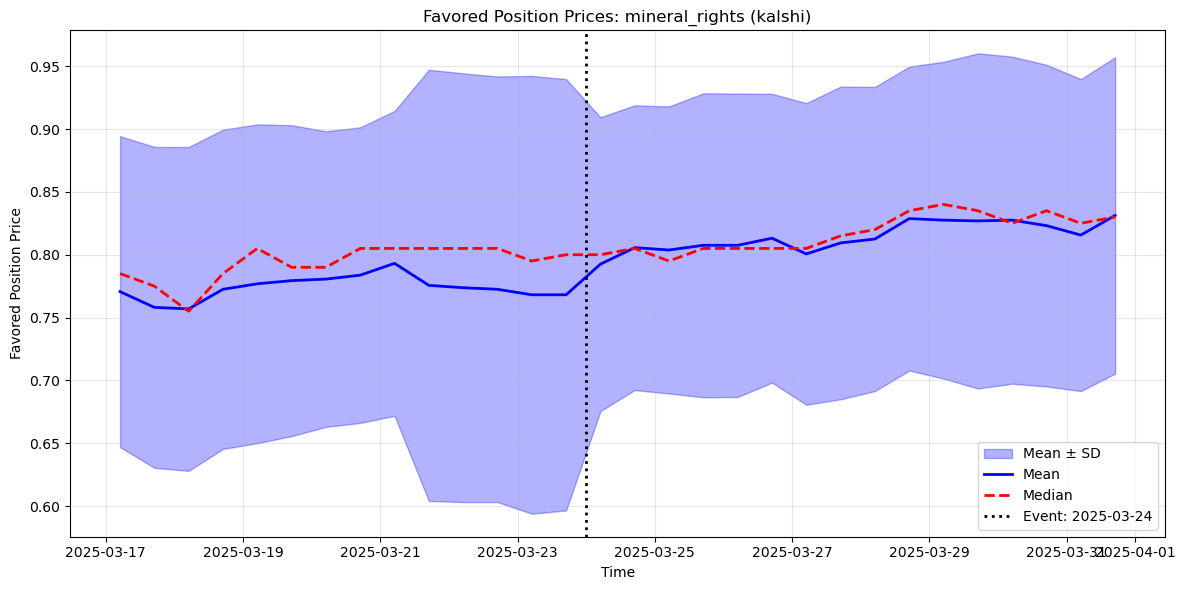

Processing exports\mineral_rights_pm_wide.csv


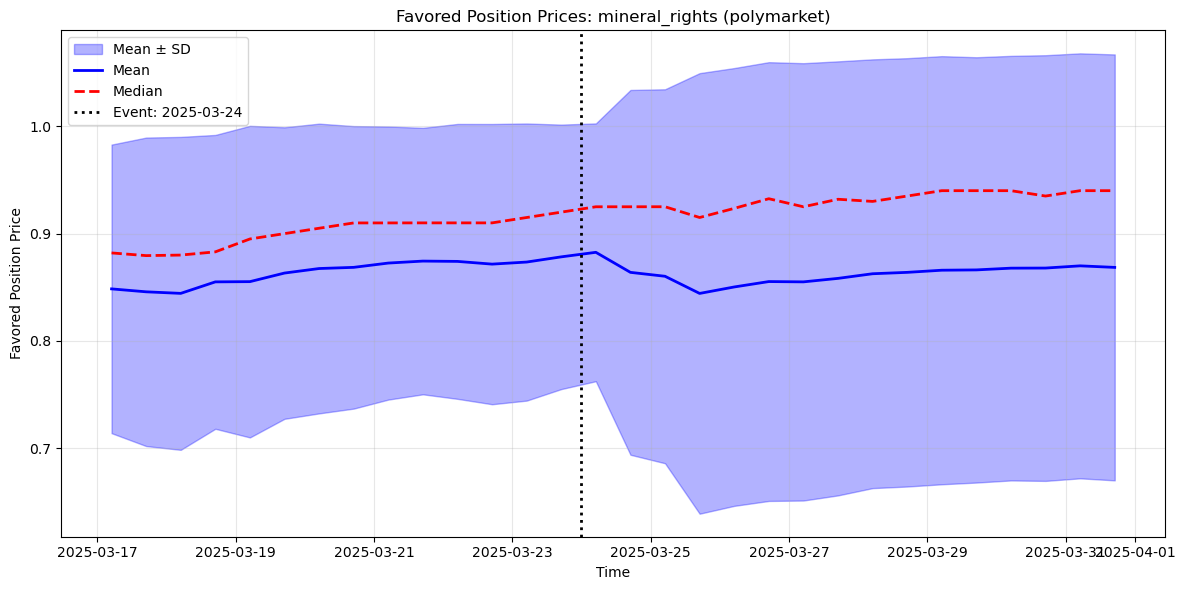

Processing exports\zelensky_suit_k_wide.csv


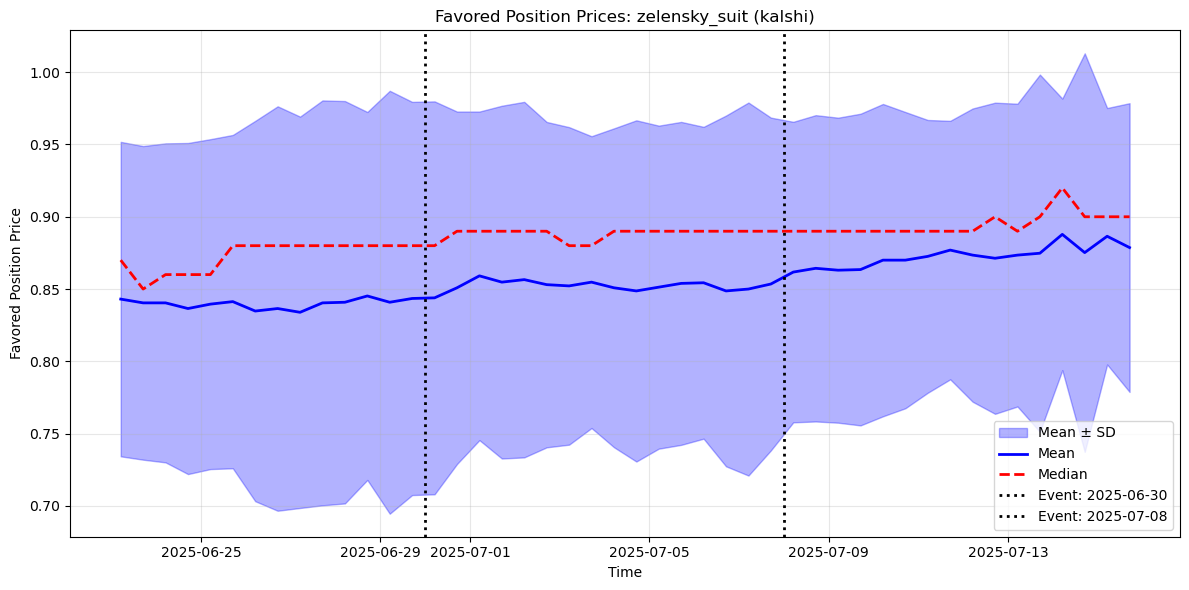

Processing exports\zelensky_suit_pm_wide.csv


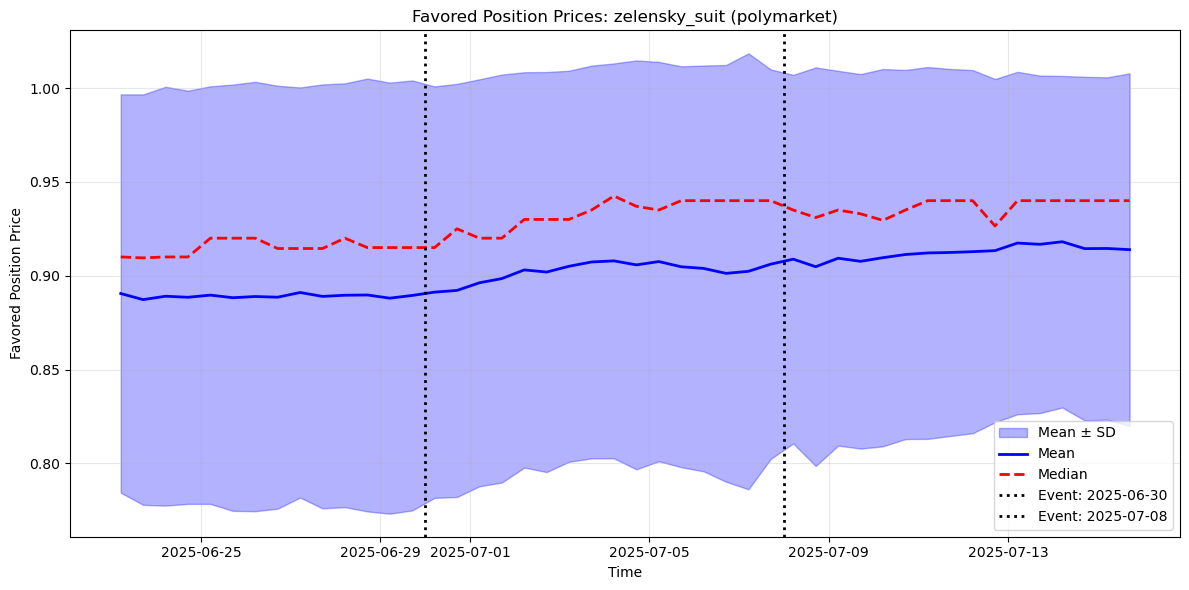

In [18]:
# Define files and event dates by searching exports directory
import glob

wide_files = glob.glob('exports/*_wide.csv')

files_and_events = {}
for file_path in wide_files:
    filename = os.path.basename(file_path)
    if '_k_wide' in filename:
        platform = 'kalshi'
        slug = filename.split('_k_wide')[0]
    elif '_pm_wide' in filename:
        platform = 'polymarket'
        slug = filename.split('_pm_wide')[0]
    else:
        continue
    
    # Event dates
    if slug == 'zelensky_suit':
        event_dates = ['2025-06-30', '2025-07-08']
    else:
        event_dates = ['2025-03-24']
    
    if slug not in files_and_events:
        files_and_events[slug] = {'event_dates': event_dates, 'files': []}
    files_and_events[slug]['files'].append(file_path)

# Process each slug
for slug, config in files_and_events.items():
    for file_path in config['files']:
        if os.path.exists(file_path):
            print(f"Processing {file_path}")
            try:
                df, sorted_dates = load_and_process_wide_file(file_path)
                agg_df = aggregate_favored_prices(df)
                platform = 'kalshi' if '_k_wide' in file_path else 'polymarket'
                plot_favored_aggregates(agg_df, sorted_dates, config['event_dates'], slug, platform)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
        else:
            print(f"File not found: {file_path}")